# Ensemblemetoder Projekt

## 0. Projektöversikt

### Syfte
Syftet med detta projekt är att analysera ett dataset och använda ensemblemetoder inom supervised machine learning för att skapa en modell som kan förutsäga [målvariabel].

### Frågeställning
Kan vi med hjälp av ensemblemetoder som Random Forest eller XGBoost förutsäga [målvariabel] baserat på datasetets variabler?

### Metod
I projektet används:

Exploratory Data Analysis (EDA)
Supervised machine learning
Ensemblemetoder (Random Forest och/eller XGBoost)
Hyperparameter tuning
Modellutvärdering
Feature Importance och Permutation Importance
(Valfritt) PCA eller UMAP
(Valfritt) jämförelse mellan flera modeller

## 1. Import av bibliotek
Vi importerar bibliotek för dataanalys, visualisering och maskininlärning.

In [2]:
# Grundläggande bibliotek
import pandas as pd
import numpy as np

# Visualisering
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - data split och preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Sklearn - modeller
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Sklearn - utvärdering
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Feature importance / permutation importance
from sklearn.inspection import permutation_importance

# Classification report och modellutvärdering
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score, 
    confusion_matrix,
    ConfusionMatrixDisplay, 
    RocCurveDisplay
) 

# Grid Search och Cross Validation
from sklearn.model_selection import GridSearchCV

# Permutation importance
from sklearn.inspection import permutation_importance

# PCA och UMAP
from sklearn.decomposition import PCA
import umap.umap_ as umap

Vi importerar bibliotek för dataanalys, visualisering, preprocessing, modellering och utvärdering. 
Eftersom uppgiften fokuserar på ensemblemetoder importerar vi särskilt Decision Tree och Random Forest. 
Vi importerar också verktyg för att utvärdera modellen samt analysera feature importance och permutation importance.

## 2. Dataset

### Beskrivning av dataset

Datasetet innehåller information om hotellbokningar från två typer av hotell: city hotel och resort hotel.  
Syftet är att undersöka vilka faktorer som påverkar om en bokning blir avbokad eller inte.

Datasetet innehåller information om bland annat bokningstid, vistelselängd, antal gäster, kundtyp, marknadssegment, tidigare avbokningar, special requests och pris per natt.

### Datasetinformation

Antal observationer: 119390   
Antal variabler: visas med 32
Typ av problem: Klassificering

### Target-variabel

Target-variabeln är `is_canceled`.

Den visar om en hotellbokning blev avbokad eller inte.

0 = Bokningen blev inte avbokad  
1 = Bokningen blev avbokad

### Variabler

Datasetet innehåller både numeriska och kategoriska variabler.  
Exempel på numeriska variabler är `lead_time`, `adults`, `children`, `adr` och `previous_cancellations`.  
Exempel på kategoriska variabler är `hotel`, `arrival_date_month`, `market_segment`, `deposit_type` och `customer_type`.



In [3]:
# Läs in datasetet
df = pd.read_csv("hotel_bookings.csv")

# Visa de första 5 raderna 
print(df.head())

# Visa dataset dimensioner 
print(df.shape)

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

## 3. Dataöversikt

### Syfte

I denna del undersöker vi datasetets struktur innan datarening och modellering.  
Vi kontrollerar datatyper, saknade värden, dubletter, klassfördelning och grundläggande statistik.

Syftet är att förstå vilka problem som finns i datan och vilka steg som behövs i dataförberedelsen.

### Vad vi undersöker

- Datasetets storlek
- Datatyper
- Saknade värden
- Dubletter
- Klassfördelning i target-variabeln
- Grundläggande statistik för numeriska variabler
- Antal unika värden i varje kolumn

In [4]:
# Visa infromation om dataset först 
df.info()

# Visa statiska sammanfattning för numeriska variabler 
display(df.describe())

# Visa antal arder och kolumner
print("Datasets dimensioner:", df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


Datasets dimensioner: (119390, 32)


In [5]:
# Kontrollera saknade värde i varje kolumn 
missing_values = df.isnull().sum()

# Visa bara kolumner med saknade värde 
missing_values[missing_values > 0]

children         4
country        488
agent        16340
company     112593
dtype: int64

In [6]:
# Kontrollera antal duplicerade data 
duplicates = df.duplicated().sum()

print("Antal duplicerade rader:", duplicates)

Antal duplicerade rader: 31994


In [7]:
# Kontrollera fördelningen av target-variabeln 
print(df["is_canceled"].value_counts())

# Kontrollera fördelningen i procent 
print(df["is_canceled"].value_counts(normalize=True) * 100)

is_canceled
0    75166
1    44224
Name: count, dtype: int64
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


In [8]:
# Kontrollera datatyper 
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [9]:
# Kontrollera antal unika värden per kolumn
df.nunique()

hotel                                2
is_canceled                          2
lead_time                          479
arrival_date_year                    3
arrival_date_month                  12
arrival_date_week_number            53
arrival_date_day_of_month           31
stays_in_weekend_nights             17
stays_in_week_nights                35
adults                              14
children                             5
babies                               5
meal                                 5
country                            177
market_segment                       8
distribution_channel                 5
is_repeated_guest                    2
previous_cancellations              15
previous_bookings_not_canceled      73
reserved_room_type                  10
assigned_room_type                  12
booking_changes                     21
deposit_type                         3
agent                              333
company                            352
days_in_waiting_list     

### Observationer

Datasetet innehåller 119390 observationer och 32 variabler.

Datasetet innehåller både numeriska och kategoriska variabler.  
Numeriska variabler inkluderar till exempel `lead_time`, `stays_in_week_nights`, `adults`, `children`, `adr` och `total_of_special_requests`.  
Kategoriska variabler inkluderar till exempel `hotel`, `arrival_date_month`, `meal`, `country`, `market_segment`, `deposit_type` och `customer_type`.

Kontrollen av saknade värden visar att vissa kolumner har missing values.  
Kolumnen `children` har endast 4 saknade värden, medan `country`, `agent` och särskilt `company` har fler saknade värden.

Datasetet innehåller också 31994 duplicerade rader.  
Detta behöver undersökas vidare i dataförberedelsen, eftersom dubletter kan påverka modellens träning.

Target-variabeln `is_canceled` visar att 75166 bokningar inte blev avbokade och 44224 bokningar blev avbokade.  
Det motsvarar cirka 62.96 % icke-avbokade bokningar och 37.04 % avbokade bokningar.

Klassfördelningen är därför något obalanserad, men inte extremt obalanserad.

### Tolkning

Dataöversikten visar att datasetet behöver preprocessing innan modellering.

Eftersom flera variabler är kategoriska behöver de kodas om till numeriska värden innan de kan användas i maskininlärningsmodeller.

Saknade värden behöver hanteras i nästa steg.  
För kolumner med få saknade värden kan imputering vara lämpligt, medan kolumner med väldigt många saknade värden kan behöva tas bort eller behandlas separat.

Dubletter behöver också hanteras i dataförberedelsen.  
Eftersom antalet duplicerade rader är relativt högt kan de påverka analysen och modellens resultat.

Klassfördelningen visar att datasetet är något obalanserat.  
Därför räcker det inte att bara titta på accuracy vid modellutvärdering.  
Vi behöver även använda mått som precision, recall, F1-score och confusion matrix.

Skalning är inte nödvändigt för Random Forest, eftersom trädmodeller inte påverkas mycket av variablernas skala.  
Däremot kan skalning bli relevant om vi senare använder PCA eller jämför med modeller som är känsliga för skala.

## 4. Dataförberedelse

### Syfte

Syftet med dataförberedelsen är att göra datasetet redo för maskininlärning.

I detta steg hanterar vi saknade värden, dubletter, irrelevanta kolumner och kategoriska variabler.  
Vi tar också bort kolumner som kan skapa data leakage.

Data leakage betyder att modellen får information som den egentligen inte skulle ha haft innan prediktionen görs.

In [10]:
# Skapa en kopia av originaldatan 
df_clean = df.copy()

# Ta bort duplicerade rader 
df_clean = df_clean.drop_duplicates()

# Kontrollera ny storlek
print("Ny dimension efter bortagning av dubletter:", df_clean.shape)

Ny dimension efter bortagning av dubletter: (87396, 32)


In [11]:
# Fyll saknade värden i childen med 0 
df_clean["children"] = df_clean["children"].fillna(0)

# Fyll saknade värden i country med "Unknown"
df_clean["country"] = df_clean["country"].fillna("Unknown")

# Ta bort kolumnerna agent och company 
df_clean = df_clean.drop(columns=["agent", "company"])

# Kontrollera saknade värden igen
df_clean.isnull().sum()[df_clean.isnull().sum() > 0]

Series([], dtype: int64)

In [12]:
# Ta bort kolumnerna som ka skapa data Leakage 
df_clean = df_clean.drop(columns=["reservation_status", "reservation_status_date"])

Kolumnerna `reservation_status` och `reservation_status_date` togs bort eftersom de kan skapa data leakage.  
De beskriver bokningens slutliga status och kan därför indirekt avslöja målvariabeln `is_canceled`.

In [13]:
# Skapa features och target 
X = df_clean.drop("is_canceled", axis=1)
y = df_clean["is_canceled"]

In [14]:
## Encoding av kategoriksa variabler 
# Gör om kategoriska variabler till numeriska dummy-variabler 
X_encoded = pd.get_dummies(X, drop_first=True)

# Kontrollera ny form 
print("Form efter encoding", X_encoded.shape)

Form efter encoding (87396, 246)


In [15]:
# Dela upp data i träningsdata och testdata 
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
## Kontrollera split 
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

# Kontrolllera klassfördelning i träningsdata
print(y_train.value_counts(normalize=True) * 100)

# Kontrollera klassfördelning i testdata 
print(y_test.value_counts(normalize=True) * 100)

X_train: (69916, 246)
X_test: (17480, 246)
is_canceled
0    72.509869
1    27.490131
Name: proportion, dtype: float64
is_canceled
0    72.511442
1    27.488558
Name: proportion, dtype: float64


### Tolkning

Efter borttagning av duplicerade rader minskade datasetet från 119390 rader till 87396 rader.  
Det betyder att 31994 duplicerade rader togs bort. Detta gör datasetet mer representativt och minskar risken att modellen tränas på upprepade observationer.

Efter hantering av saknade värden finns inga missing values kvar i datasetet.  
Det innebär att datan nu är komplett och kan användas för maskininlärning.

Efter encoding ökade antalet variabler från 32 till 246.  
Det beror på att kategoriska variabler, till exempel `country`, `market_segment` och `customer_type`, gjordes om till numeriska dummy-variabler.

Datan delades upp i träningsdata och testdata.  
Träningsdata innehåller 69916 observationer och testdata innehåller 17480 observationer.

Klassfördelningen är nästan identisk i träningsdata och testdata.  
I båda fallen är ungefär 72.5 % av bokningarna inte avbokade och ungefär 27.5 % avbokade.

Det visar att stratifiering fungerade korrekt.  
Det är viktigt eftersom modellen då tränas och testas på data med liknande klassfördelning.

Datasetet är fortfarande något obalanserat, eftersom det finns fler icke-avbokade bokningar än avbokade bokningar.  
Därför bör modellen senare utvärderas med flera mått, inte bara accuracy, utan även precision, recall, F1-score och confusion matrix.

## 5. Exploratory Data Analysis (EDA)

### Syfte

Syftet med EDA är att förstå datasetet bättre innan modellering.

Vi undersöker:
- Fördelningar av variabler
- Relationer mellan variabler
- Skillnader mellan avbokade och icke-avbokade bokningar
- Eventuella outliers
- Korrelationer mellan numeriska variabler

EDA hjälper oss att identifiera viktiga mönster i datan och förstå vilka variabler som kan vara relevanta för modelleringen.

### Klassfördelning och visualisering 

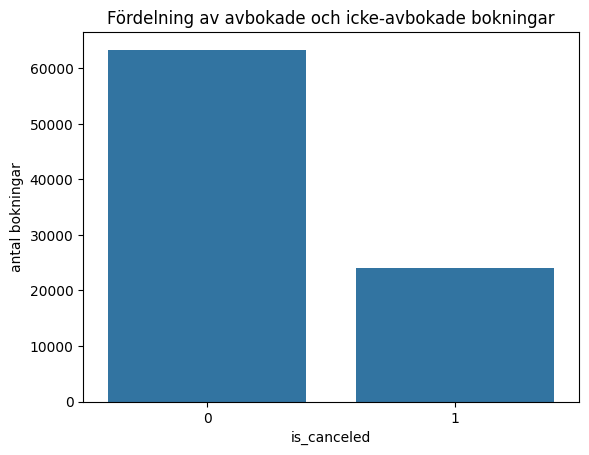

In [17]:
# Visualisera klassfördelningen för target-varaibeln 
sns.countplot(x="is_canceled", data=df_clean)

plt.title("Fördelning av avbokade och icke-avbokade bokningar")
plt.xlabel("is_canceled")
plt.ylabel("antal bokningar")

plt.show()


### Observation

Diagrammet visar att majoriteten av bokningarna inte blev avbokade.  
Samtidigt är andelen avbokade bokningar fortfarande relativt stor, vilket gör datasetet relevant för klassificering och prediktiv analys.

### Hotelltyp vs avbokningar 

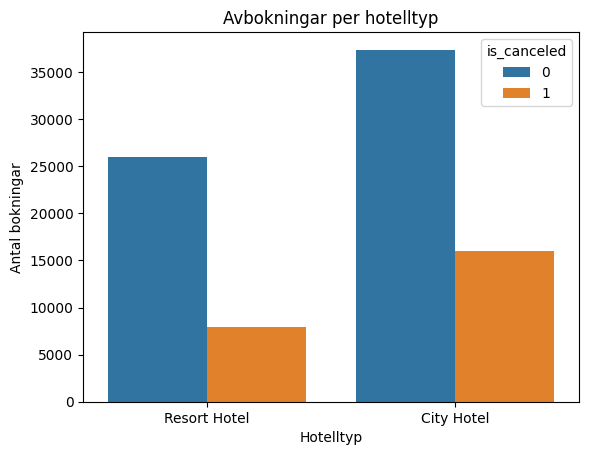

In [18]:
# Visualisera hotelltyp och avbokningar 
sns.countplot(x="hotel", hue="is_canceled", data=df_clean)

plt.title("Avbokningar per hotelltyp")
plt.xlabel("Hotelltyp")
plt.ylabel("Antal bokningar")

plt.legend(title="is_canceled")

plt.show()

### Observation

Diagrammet visar att City Hotel har fler bokningar totalt men också fler avbokningar jämfört med Resort Hotel.

Båda hotelltyperna har fler icke-avbokade bokningar än avbokade bokningar, men andelen avbokningar verkar vara högre för City Hotel.

Detta tyder på att hotelltyp kan vara en viktig variabel för att förutsäga om en bokning blir avbokad eller inte.

### Lead time vs avbokningar 

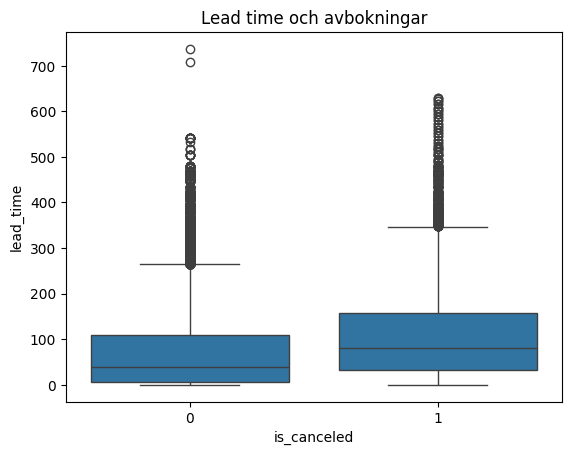

In [19]:
# Jämför Lead_time mellan avbokade och icke-avbokade bokningar 
sns.boxplot(x="is_canceled", y="lead_time", data=df_clean)

plt.title("Lead time och avbokningar")
plt.xlabel("is_canceled")
plt.ylabel("lead_time")

plt.show()

### Observation

Boxploten visar att avbokade bokningar (`is_canceled = 1`) generellt har högre `lead_time` än icke-avbokade bokningar (`is_canceled = 0`).

Det innebär att bokningar som görs långt i förväg verkar ha högre sannolikhet att bli avbokade.

Diagrammet visar också flera outliers, vilket betyder att vissa bokningar gjordes extremt långt innan ankomst.

### ADR (Pris per natt) vs avbokningar 

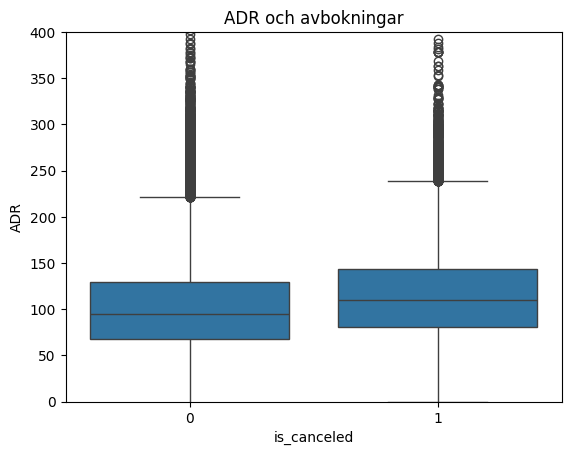

In [20]:
# Jämför pris per natt mellan avbokade och icke-avbokdade bokningar 
sns.boxplot(x="is_canceled", y="adr", data=df_clean)

plt.ylim(0, 400)

plt.title("ADR och avbokningar")
plt.xlabel("is_canceled")
plt.ylabel("ADR")

plt.show()

### Observation

Boxploten visar att avbokade bokningar (`is_canceled = 1`) generellt har något högre ADR än icke-avbokade bokningar (`is_canceled = 0`).

Det tyder på att dyrare bokningar kan ha högre sannolikhet att bli avbokade.

Diagrammet visar också flera outliers med mycket höga ADR-värden, vilket innebär att vissa bokningar hade extremt höga priser per natt.

### Special requests vs avbokningar

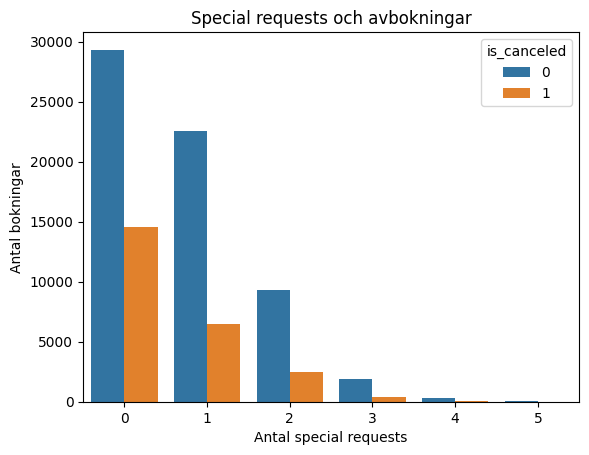

In [21]:
# Jämför antal special requests mellan avbokade och icke-avbokade bokningar 
sns.countplot(x="total_of_special_requests", hue="is_canceled", data=df_clean)


plt.title("Special requests och avbokningar")
plt.xlabel("Antal special requests")
plt.ylabel("Antal bokningar")

plt.show()

### Observation

Diagrammet visar att kunder med fler special requests generellt verkar ha lägre sannolikhet att avboka sina bokningar.

När antalet special requests ökar minskar andelen avbokade bokningar jämfört med icke-avbokade bokningar.

Detta kan tyda på att kunder som gör fler special requests är mer engagerade i sin bokning och därför mindre benägna att avboka.

### Korrlation Matrix

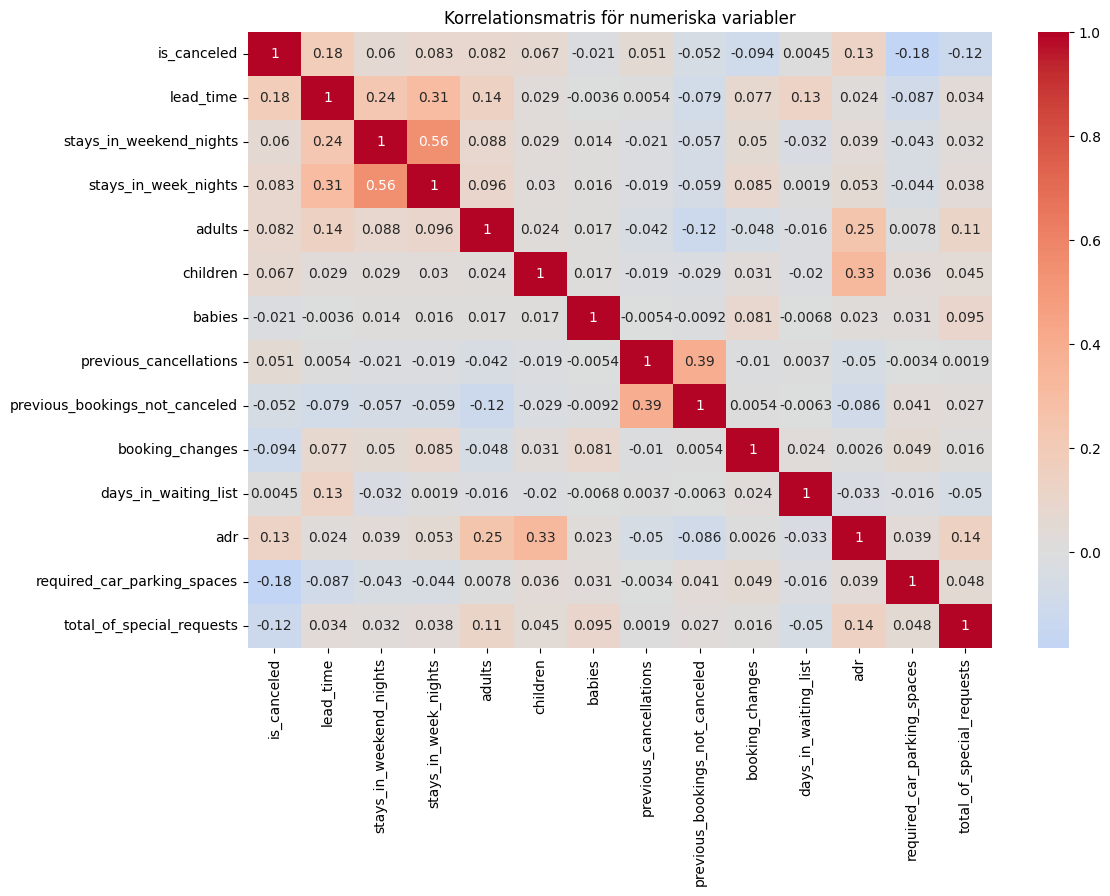

In [22]:
# Välj viktiga numeriska variabler för korrelationsanalys
numeric_cols = [
    "is_canceled",
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

# Skapa korrelationsmatris
corr_matrix = df_clean[numeric_cols].corr()

# Visualisera korrelationsmatrisen
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)

plt.title("Korrelationsmatris för numeriska variabler")
plt.show()


### Observation

Korrelationsmatrisen visar att `lead_time` har en positiv korrelation med `is_canceled` på cirka 0.18.  
Det innebär att längre tid mellan bokning och ankomst verkar hänga ihop med högre sannolikhet för avbokning.

`required_car_parking_spaces` har en negativ korrelation med `is_canceled` på cirka -0.18.  
Det betyder att bokningar med parkeringsplats verkar ha lägre sannolikhet att bli avbokade.

`total_of_special_requests` har också en negativ korrelation med `is_canceled` på cirka -0.12.  
Det stödjer tidigare observation att kunder med fler special requests verkar vara mindre benägna att avboka.

Korrelationerna är inte extremt starka, men de visar tydliga riktningar och hjälper oss att identifiera variabler som kan vara relevanta för modellen.

### Sammanfattning av EDA

EDA visar att flera variabler verkar ha samband med avbokningar.

`lead_time` verkar vara en viktig variabel, eftersom bokningar som görs långt i förväg oftare blir avbokade.

`hotel` verkar också påverka avbokningar, eftersom City Hotel har fler avbokningar än Resort Hotel.

`adr` visar att avbokade bokningar generellt har något högre prisnivå.

`total_of_special_requests` verkar ha ett negativt samband med avbokningar. Kunder som gör fler special requests verkar vara mindre benägna att avboka.

Korrelationsmatrisen visar att sambanden inte är extremt starka, men flera variabler visar tydliga riktningar. Därför är det relevant att använda maskininlärning för att kombinera flera variabler samtidigt och förutsäga avbokningar.

## 6. Basmodell – Ensemblemetod

### Modell: Random Forest

I detta steg använder vi Random Forest, som är en ensemblemetod baserad på flera beslutsträd.

Random Forest fungerar genom att träna många beslutsträd på olika delar av datan och sedan kombinera deras prediktioner.  
Slutresultatet bestäms genom majoritetsröstning mellan träden.

Metoden passar bra för detta dataset eftersom den fungerar effektivt på både numeriska och kategoriska variabler och kan identifiera komplexa mönster i datan.

### Skapa och träna modellen 

In [23]:
# Skapa Random Forest.modellen
rf_model = RandomForestClassifier(random_state=42)

# Träna modellen 
rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Generera prediktioner

In [24]:
# Gör prediktion på testdata
y_pred = rf_model.predict(X_test)

# Beräkna sannolikheter för ROC-AUC
y_prob = rf_model.predict_proba(X_test)[:,1]


# Visa exempel på prediktioner
print("Exempel på modellens prediktioner")
print("Tabellen visar ett slumpmässigt urval av faktiska och predikterade avbokningar.")
print("0 = inte avbokad bokning, 1 = avbokad bokning.")

predictions_df = pd.DataFrame({
    "Faktisk avbokning": y_test.values,
    "Predikterad avbokning": y_pred
})

# Lägg till kolumn för korrekt/fel
predictions_df["Resultat"] = np.where(
    predictions_df["Faktisk avbokning"] ==
    predictions_df["Predikterad avbokning"],
    "✔️ Korrekt",
    "❌ Fel"
)

# Visa slumpmässigt urval
predictions_df.sample(10, random_state=42).reset_index(drop=True)

Exempel på modellens prediktioner
Tabellen visar ett slumpmässigt urval av faktiska och predikterade avbokningar.
0 = inte avbokad bokning, 1 = avbokad bokning.


,Faktisk avbokning,Predikterad avbokning,Resultat
0,0,0,✔️ Korrekt
1,0,0,✔️ Korrekt
2,1,1,✔️ Korrekt
3,0,0,✔️ Korrekt
4,0,0,✔️ Korrekt
5,0,1,❌ Fel
6,0,0,✔️ Korrekt
7,0,0,✔️ Korrekt
8,0,0,✔️ Korrekt
9,1,1,✔️ Korrekt


### Kommentar

Modellen genererade prediktioner för testdatan genom att klassificera bokningar som avbokade eller icke-avbokade.

Dessa prediktioner används sedan i nästa steg för att utvärdera modellens prestanda med flera olika utvärderingsmått.

## 7. Modellutvärdering

Efter att modellen tränats utvärderades dess prestanda med flera olika klassificeringsmått.

Eftersom detta är ett klassificeringsproblem är det viktigt att inte bara analysera accuracy, utan även precision, recall, F1-score och ROC-AUC.

Dessa mått hjälper oss att förstå hur väl modellen identifierar avbokningar och vilka typer av fel modellen gör.

### 7.1 Utvärderingsmetoder
- Accuracy: Visar hur stor andel observationer som klassificeras korrekt totalt.

- Precision: Visar hur många av de förutsagda avbokningarna som faktiskt var avbokningar.

- Recall: Recall är särskilt viktigt eftersom missade avbokningar kan skapa ekonomiska förluster och sämre planering för hotellet.

- F1-score: F1-score balanserar precision och recall och används för att få en mer rättvis bild av modellens prestanda.

- ROC-AUC: ROC-AUC mäter modellens förmåga att skilja mellan klasserna. Ett värde nära 1 innebär mycket bra klassificeringsförmåga.

### 7.2 Resultat

In [25]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.3f}")

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.3f}")

# Classification Report
print(classification_report(y_test, y_pred))

Accuracy: 0.841
ROC-AUC: 0.898
              precision    recall  f1-score   support

           0       0.86      0.93      0.89     12675
           1       0.76      0.61      0.68      4805

    accuracy                           0.84     17480
   macro avg       0.81      0.77      0.79     17480
weighted avg       0.84      0.84      0.84     17480



### 7.3 Confusion Matrix

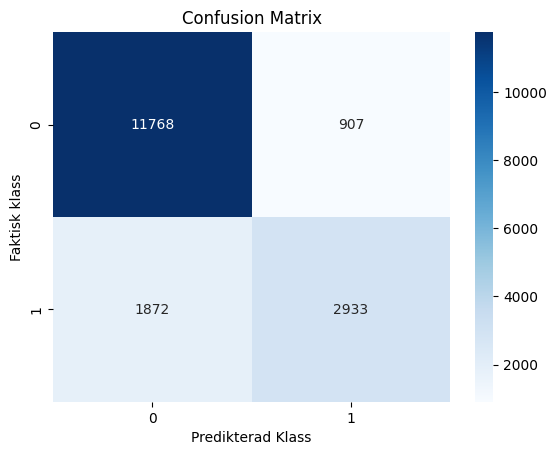

In [26]:
# Skapa confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisera confusion matrix 
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predikterad Klass")
plt.ylabel("Faktisk klass")

plt.show()

### 7.4 ROC-kurva

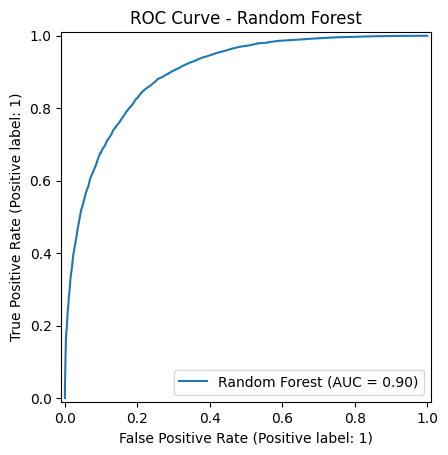

In [27]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name="Random Forest"
)

plt.title("ROC Curve - Random Forest")

plt.show()

### 7.5 Tolkning

Random Forest-modellen uppnår en accuracy på cirka 84.2 %, vilket innebär att modellen klassificerar majoriteten av bokningarna korrekt.

ROC-AUC är cirka 0.897, vilket visar att modellen har god förmåga att skilja mellan avbokade och icke-avbokade bokningar.

Classification report visar att modellen presterar bättre för klass 0 än klass 1. Recall för avbokningar är lägre, vilket betyder att modellen fortfarande missar vissa avbokningar.

Confusion Matrix visar att modellen är bättre på att identifiera icke-avbokade bokningar än avbokade bokningar. Det finns fortfarande ett antal avbokade bokningar som modellen missar, vilket är viktigt eftersom hotellet särskilt vill kunna identifiera bokningar med hög avbokningsrisk.

Trots detta presterar modellen överlag bra och resultaten visar att Random Forest är användbar för att identifiera mönster i hotellbokningar och kan bidra till bättre planering och minskade ekonomiska förluster.

## 8. Hyperparameter Tuning

### 8.1 Syfte

Syftet med hyperparameter tuning är att optimera modellens parametrar för att förbättra prestanda och generalisering.

Genom att testa olika kombinationer av parametrar kan modellen hitta bättre balans mellan precision och överanpassning.

### 8.2 Parametrar som testas

Följande hyperparametrar testas för Random Forest-modellen:

- n_estimators: antal beslutsträd i modellen
- max_depth: maximalt djup på varje beslutsträd
- min_samples_split: minsta antal observationer för att dela en nod
- min_samples_leaf: minsta antal observationer i ett blad

In [28]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

### 8.3 GridSearchCV

In [29]:
rf = RandomForestClassifier(
    random_state=42
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


/Users/victoria/Documents/aikurs/venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter cand

### 8.4 Utvärdering av optimerad modell


In [30]:
best_rf = grid_search.best_estimator_

best_pred = best_rf.predict(X_test)
best_prob = best_rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, best_pred))

print(f"ROC-AUC: {roc_auc_score(y_test, best_prob):.3f}")

              precision    recall  f1-score   support

           0       0.86      0.93      0.89     12675
           1       0.77      0.60      0.67      4805

    accuracy                           0.84     17480
   macro avg       0.81      0.77      0.78     17480
weighted avg       0.83      0.84      0.83     17480

ROC-AUC: 0.902


### 8.5 Tolkning

Efter hyperparameter tuning förbättrades modellens ROC-AUC från cirka 0.898 till 0.902, vilket visar en liten men positiv förbättring av modellens klassificeringsförmåga.

Precision för avbokningar ökade också något, vilket betyder att modellen blev något bättre på att korrekt identifiera bokningar med hög avbokningsrisk.

Resultaten visar att fler beslutsträd och justerade parametrar hjälpte modellen att skapa bättre balans mellan komplexitet och generalisering.

Förbättringen är relativt liten, men modellen presterar stabilt och visar inga tydliga tecken på överanpassning.

## 9. Feature Importance

### 9.1 Introduktion

Feature Importance används för att analysera vilka variabler som hade störst påverkan på modellens prediktioner.

Det hjälper oss att förstå vilka faktorer som är viktigast för att förutsäga hotellavbokningar och ger även insikt i vilka variabler som kan vara mest relevanta för verksamheten.

### 9.2 Beräkning av Feature Importance

In [31]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,lead_time,0.129288
14,adr,0.084556
16,total_of_special_requests,0.064293
3,arrival_date_day_of_month,0.058138
2,arrival_date_week_number,0.053788
167,country_PRT,0.050290
5,stays_in_week_nights,0.043128
215,market_segment_Online TA,0.033298
15,required_car_parking_spaces,0.032545
1,arrival_date_year,0.028369


### 9.3 Visualisering

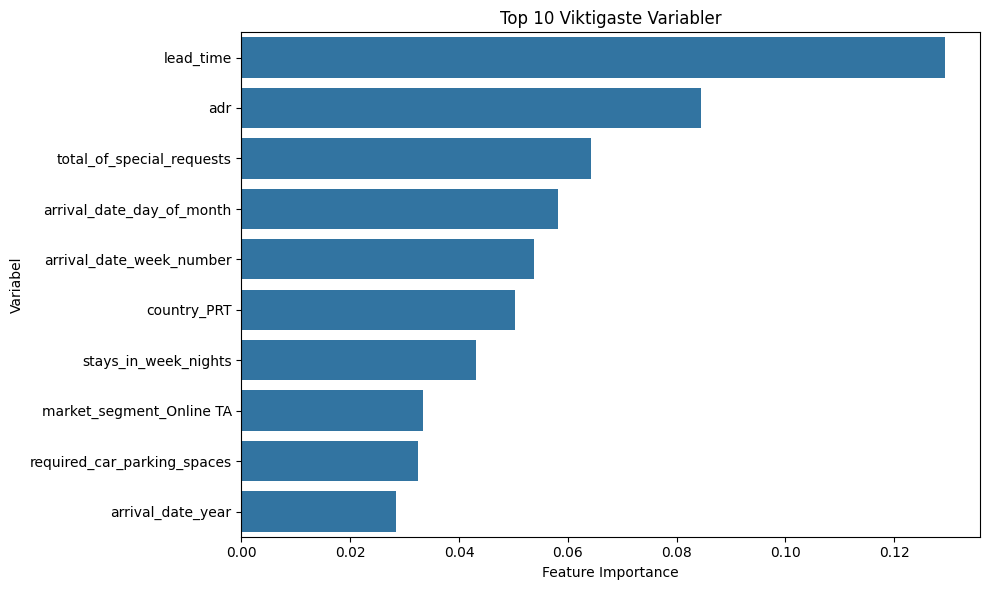

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Viktigaste Variabler")

plt.xlabel("Feature Importance")
plt.ylabel("Variabel")

plt.tight_layout()
plt.show()

### 9.4 Tolkning

Feature Importance visar att vissa variabler hade betydligt större påverkan på modellens prediktioner än andra.

Variabler som lead_time, adr och total_of_special_requests verkar vara särskilt viktiga för att förutsäga avbokningar.

Det tyder på att bokningsmönster, prisnivåer och kundbeteenden påverkar sannolikheten för att en bokning avbokas.

Informationen kan vara värdefull för hotell eftersom den hjälper verksamheten att förstå vilka typer av bokningar som har högre risk för avbokning.

Hotell skulle exempelvis kunna använda denna information för bättre planering, riktade erbjudanden eller förbättrad kundkommunikation.

## 10. Permutation Importance

### 10.1 Introduktion

Permutation Importance används för att analysera hur mycket modellens prestanda påverkas när värdena för en variabel slumpas om.

Om modellens prestanda försämras mycket betyder det att variabeln är viktig för modellens prediktioner.

### 10.2 Beräkning

In [33]:
# Ta ett mindre urval av testdatan för snabbare beräkning
sample_X = X_test.sample(3000, random_state=42)
sample_y = y_test.loc[sample_X.index]

# Beräkna permutation importance
perm_importance = permutation_importance(
    best_rf,
    sample_X,
    sample_y,
    n_repeats=3,
    random_state=42
)

In [34]:
perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_importance.importances_mean
})

perm_df = perm_df.sort_values(
    by='Importance',
    ascending=False
)

perm_df.head(10)

,Feature,Importance
16,total_of_special_requests,0.045556
0,lead_time,0.042667
167,country_PRT,0.037444
215,market_segment_Online TA,0.029222
14,adr,0.022556
1,arrival_date_year,0.021778
232,assigned_room_type_D,0.012667
15,required_car_parking_spaces,0.010889
17,hotel_Resort Hotel,0.009889
10,previous_cancellations,0.008556


### 10.3 Visualisering

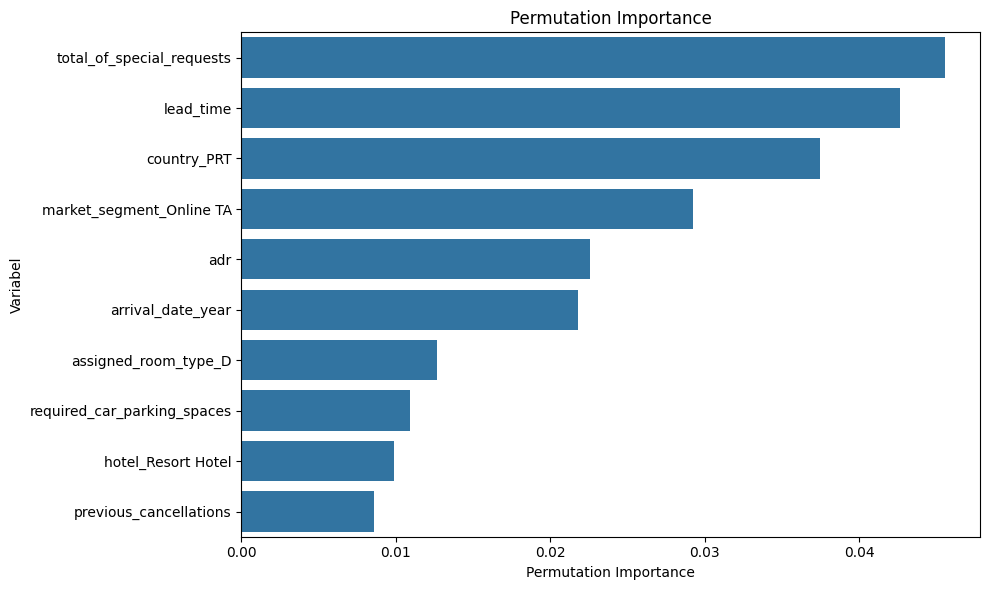

In [35]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=perm_df.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Permutation Importance")

plt.xlabel("Permutation Importance")
plt.ylabel("Variabel")

plt.tight_layout()

plt.show()

### 10.4 Tolkning

Permutation Importance visar vilka variabler som hade störst påverkan på modellens prestanda när deras värden slumpades om.

Resultaten visar att variabler som total_of_special_requests, lead_time och country_PRT hade särskilt stor betydelse för modellens prediktioner.

Det tyder på att kundbeteenden, bokningsmönster och geografiska faktorer påverkar sannolikheten för att en bokning avbokas.

Variabeln total_of_special_requests verkar vara mycket viktig, vilket kan indikera att kunder som gör fler special requests är mer engagerade i sin bokning och därför mindre benägna att avboka.

Lead_time är också en viktig variabel, vilket tyder på att bokningar som görs långt i förväg har större risk att avbokas.

Resultaten liknar till stor del vanlig Feature Importance, vilket stärker modellens trovärdighet och visar att modellen identifierar stabila och relevanta mönster i datan.

## 11. PCA och UMAP

### 11.1 Introduktion
PCA (Principal Component Analysis) används för dimensionalitetsreducering.

Metoden kombinerar flera variabler till nya komponenter som försöker behålla så mycket information som möjligt från den ursprungliga datan.

Syftet är att undersöka om datan kan representeras på ett enklare sätt och visualiseras tydligare.

### 11.2 Standardisering

In [36]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_train)

### 11.3 PCA


In [37]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Förklarad varians per komponent:")
print(pca.explained_variance_ratio_)

print("\nTotal förklarad varians:")
print(pca.explained_variance_ratio_.sum())

Förklarad varians per komponent:
[0.01641658 0.0134927 ]

Total förklarad varians:
0.02990928747573178


### 11.4 PCA-visualisering

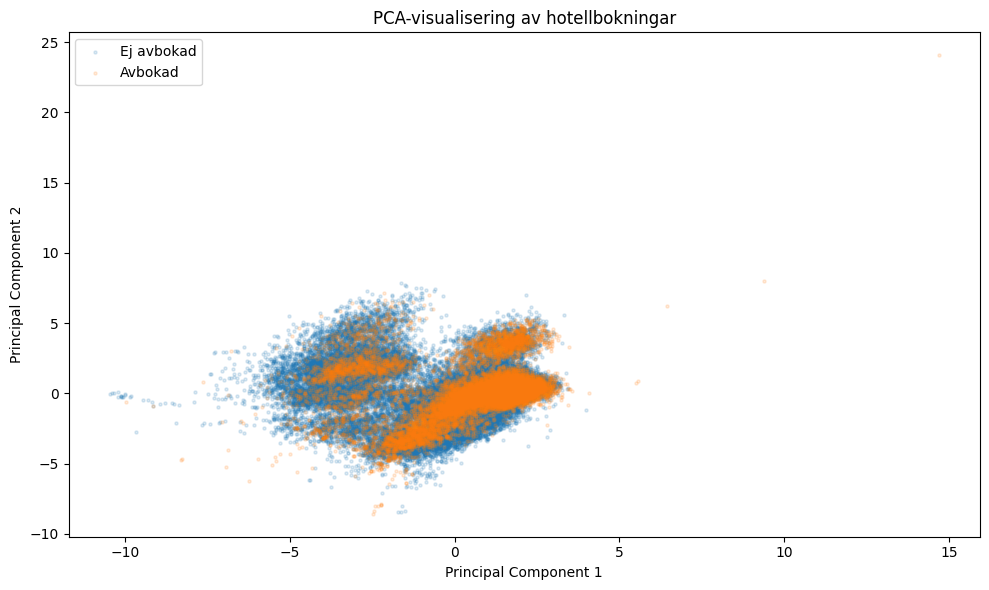

In [38]:
plt.figure(figsize=(10,6))

# Ej avbokad
plt.scatter(
    X_pca[y_train == 0, 0],
    X_pca[y_train == 0, 1],
    label="Ej avbokad",
    alpha=0.15,
    s=5
)

# Avbokad
plt.scatter(
    X_pca[y_train == 1, 0],
    X_pca[y_train == 1, 1],
    label="Avbokad",
    alpha=0.15,
    s=5
)

plt.title("PCA-visualisering av hotellbokningar")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend()

plt.tight_layout()

plt.show()

### 11.5 UMAP

In [39]:
reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.01,
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

/Users/victoria/Documents/aikurs/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/victoria/Documents/aikurs/venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


### 11.6 UMAP-visualisering

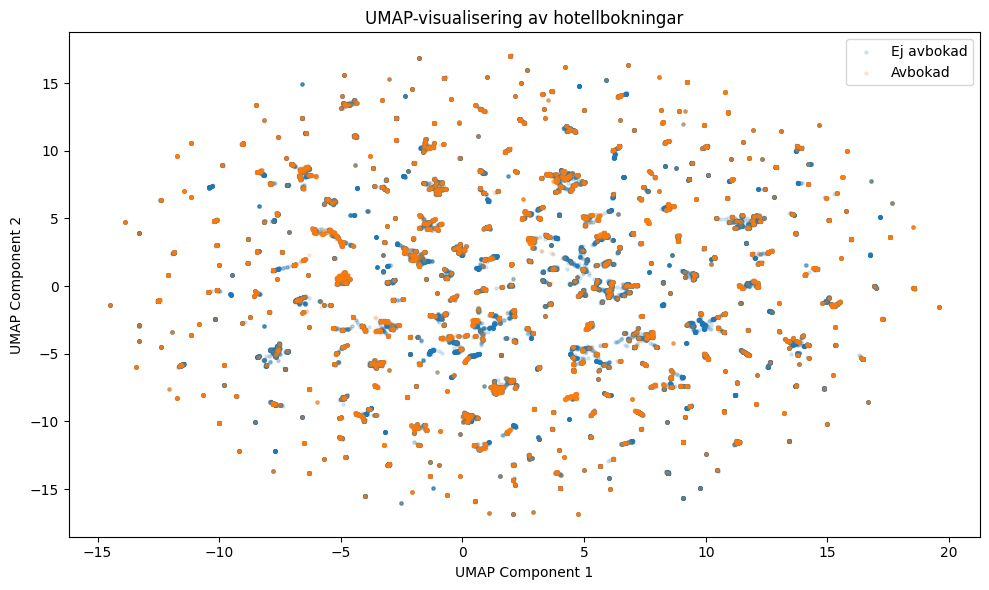

In [40]:
plt.figure(figsize=(10,6))

# Ej avbokad
plt.scatter(
    X_umap[y_train == 0, 0],
    X_umap[y_train == 0, 1],
    label="Ej avbokad",
    alpha=0.15,
    s=5
)

# Avbokad
plt.scatter(
    X_umap[y_train == 1, 0],
    X_umap[y_train == 1, 1],
    label="Avbokad",
    alpha=0.15,
    s=5
)

plt.title("UMAP-visualisering av hotellbokningar")

plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")

plt.legend()

plt.tight_layout()

plt.show()

### 11.7 Random Forest + PCA

För att undersöka hur dimensionsreducering påverkar modellens prestanda tränades även Random Forest på PCA-transformerad data.

Resultatet jämfördes sedan med den vanliga Random Forest-modellen.

In [41]:
# Standardisera data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA med 2 komponenter
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Random Forest på PCA-data
rf_pca = RandomForestClassifier(
    random_state=42
)

rf_pca.fit(X_train_pca, y_train)

# Prediktioner
rf_pca_pred = rf_pca.predict(X_test_pca)

rf_pca_prob = rf_pca.predict_proba(X_test_pca)[:,1]

# Utvärdering
rf_pca_accuracy = accuracy_score(
    y_test,
    rf_pca_pred
)

rf_pca_roc = roc_auc_score(
    y_test,
    rf_pca_prob
)

print(f"RF + PCA Accuracy: {rf_pca_accuracy:.3f}")

print(f"RF + PCA ROC-AUC: {rf_pca_roc:.3f}")

RF + PCA Accuracy: 0.685
RF + PCA ROC-AUC: 0.626


### 11.8 Tolkning

Random Forest presterade betydligt sämre efter PCA-transformering.

RF + PCA uppnådde endast en ROC-AUC på cirka 0.626 jämfört med cirka 0.902 för vanlig Random Forest.

Det tyder på att PCA reducerade viktig information i datan och att hotellbokningsdata innehåller komplexa och icke-linjära samband som är svåra att representera med ett litet antal linjära komponenter.

Resultatet stärker även slutsatsen att ensemblemetoder som Random Forest och XGBoost fungerar bättre direkt på den ursprungliga datan utan kraftig dimensionsreducering.

## 12. Jämförelse mellan modeller

### 12.1 Introduktion

För att jämföra olika maskininlärningsmodeller testades:

- Beslutsträd (Decision Tree)
- Random Forest
- XGBoost

Syftet var att undersöka hur ensemblemetoder presterar jämfört med ett enskilt beslutsträd vid klassificering av hotellavbokningar.

### 12.2 Beslutsträd (Decision Tree)
Beslutsträd användes som en enklare basmodell för att jämföra mot ensemblemetoderna Random Forest och XGBoost.

In [42]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_prob = dt_model.predict_proba(X_test)[:,1]


dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

dt_roc = roc_auc_score(
    y_test,
    dt_prob
)

print(f"Decision Tree Accuracy: {dt_accuracy:.3f}")

print(f"Decision Tree ROC-AUC: {dt_roc:.3f}")

Decision Tree Accuracy: 0.785
Decision Tree ROC-AUC: 0.735


### 12.3 XGBoost
XGBoost är en avancerad ensemblemetod baserad på boosting.

Till skillnad från Random Forest, som bygger många beslutsträd parallellt, bygger XGBoost träd sekventiellt där varje nytt träd försöker korrigera tidigare fel.

In [43]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:,1]

### 12.4 Jämförelse av resultat

In [44]:
rf_accuracy = accuracy_score(
    y_test,
    best_pred
)

rf_roc = roc_auc_score(
    y_test,
    best_prob
)

print(f"Random Forest Accuracy: {rf_accuracy:.3f}")

print(f"Random Forest ROC-AUC: {rf_roc:.3f}")

Random Forest Accuracy: 0.839
Random Forest ROC-AUC: 0.902


In [45]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_roc = roc_auc_score(
    y_test,
    xgb_prob
)

print(f"XGBoost Accuracy: {xgb_accuracy:.3f}")

print(f"XGBoost ROC-AUC: {xgb_roc:.3f}")

XGBoost Accuracy: 0.841
XGBoost ROC-AUC: 0.904


In [50]:
comparison_df = pd.DataFrame({
    'Modell': [
        'Beslutsträd',
        'Random Forest',
        'RF + PCA',
        'XGBoost'
    ],
    'Accuracy': [
        dt_accuracy,
        rf_accuracy,
        rf_pca_accuracy,
        xgb_accuracy
    ],
    'ROC-AUC': [
        dt_roc,
        rf_roc,
        rf_pca_roc,
        xgb_roc
    ]
})

comparison_df

,Modell,Accuracy,ROC-AUC
0,Beslutsträd,0.785355,0.735046
1,Random Forest,0.839474,0.902066
2,RF + PCA,0.685469,0.626271
3,XGBoost,0.840961,0.904087


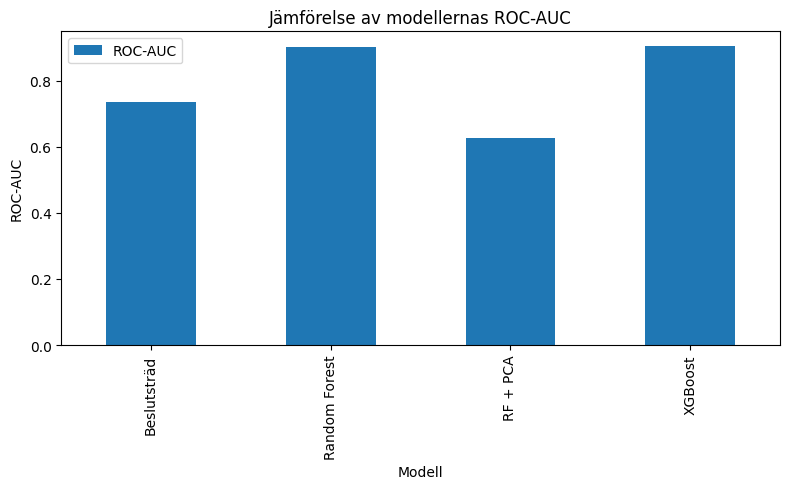

In [51]:
comparison_df.plot(
    x='Modell',
    y='ROC-AUC',
    kind='bar',
    figsize=(8,5)
)

plt.title("Jämförelse av modellernas ROC-AUC")

plt.xlabel("Modell")
plt.ylabel("ROC-AUC")

plt.tight_layout()

plt.show()

### 12.5 Tolkning

Resultaten visar tydligt att ensemblemetoder presterade bättre än ett enskilt beslutsträd.

Beslutsträdet uppnådde en ROC-AUC på cirka 0.735, vilket visar att modellen hade svårare att generalisera och identifiera komplexa mönster i datan.

Random Forest förbättrade prestandan kraftigt och uppnådde en ROC-AUC på cirka 0.902.

När Random Forest kombinerades med PCA försämrades resultatet betydligt till cirka 0.626 ROC-AUC.

Det tyder på att PCA reducerade viktig information i datan och att hotellbokningsdata innehåller komplexa och icke-linjära samband som är svåra att representera med ett litet antal linjära komponenter.

XGBoost uppnådde högst resultat med en ROC-AUC på cirka 0.904 och var den modell som bäst kunde skilja mellan avbokade och icke-avbokade bokningar.

Resultaten visar tydligt att ensemblemetoder fungerar särskilt bra för komplexa klassificeringsproblem med många variabler och icke-linjära samband.

## 13. Presentation / Databerättelse

### 13.1 Bakgrund

Hotellbranschen påverkas starkt av sena avbokningar eftersom tomma rum leder till förlorade intäkter och svårare planering.

I detta projekt analyserades hotellbokningar för att undersöka vilka faktorer som påverkar sannolikheten för avbokning.

### 13.2 Viktiga resultat

Feature Importance och Permutation Importance visade att variabler som lead_time, total_of_special_requests, market_segment och previous_cancellations hade stor betydelse för modellernas prediktioner.

Flera maskininlärningsmodeller jämfördes:

- Beslutsträd
- Random Forest
- XGBoost

Resultaten visade tydligt att ensemblemetoder presterade bättre än ett enskilt beslutsträd.

Random Forest och XGBoost kunde identifiera mer komplexa mönster i datan och uppnådde hög ROC-AUC, vilket innebär att modellerna hade god förmåga att skilja mellan avbokade och icke-avbokade bokningar.

Visualiseringar med PCA och UMAP visade även att datan innehåller komplexa och icke-linjära samband, vilket förklarar varför ensemblemetoder fungerade särskilt bra.

### 13.3 Affärsvärde

Ett hotell skulle kunna använda denna typ av modell för att:

- identifiera bokningar med hög avbokningsrisk
- förbättra planering och resursfördelning
- optimera prissättning och överbokning
- minska ekonomiska förluster

Projektet visar hur maskininlärning kan användas för att skapa affärsvärde genom bättre beslutsstöd och mer datadrivna analyser.

## 14. Slutsats

### 14.1 Sammanfattning

I detta projekt analyserades hotellbokningar för att undersöka vilka faktorer som påverkar sannolikheten för avbokning.

Flera maskininlärningsmodeller testades och jämfördes, inklusive Beslutsträd, Random Forest och XGBoost.

Resultaten visade att ensemblemetoder presterade betydligt bättre än ett vanligt beslutsträd.

XGBoost uppnådde högst ROC-AUC på cirka 0.904, medan Random Forest också presterade mycket starkt med cirka 0.902.

Feature Importance och Permutation Importance visade att variabler som:

- lead_time
- total_of_special_requests
- market_segment
- previous_cancellations

hade stor påverkan på modellernas prediktioner.

PCA och UMAP användes för att visualisera datans struktur. Resultaten visade att datan innehåller komplexa och icke-linjära samband, vilket förklarar varför ensemblemetoder fungerade särskilt bra.

Projektet visar att maskininlärning kan användas för att hjälpa hotell att identifiera bokningar med hög avbokningsrisk och därmed förbättra planering och minska ekonomiska förluster.

### 14.2 Viktiga insikter

En viktig insikt från projektet var hur stor skillnaden blev mellan ett vanligt beslutsträd och ensemblemetoder som Random Forest och XGBoost.

Det blev också tydligt att hotellbokningsdata innehåller komplexa samband som är svåra att fånga med enklare linjära metoder.

UMAP kunde visualisera lokala grupperingar bättre än PCA, vilket visade att datan innehåller många icke-linjära mönster.

Om projektet utvecklades vidare skulle fler modeller och mer avancerad hyperparameteroptimering kunna testas för att ytterligare förbättra resultaten.

Det skulle även vara möjligt att använda modellen i realtid för att hjälpa hotell att fatta snabbare och mer datadrivna beslut.

Projektet visar tydligt hur ensemblemetoder och maskininlärning kan användas för att identifiera komplexa mönster i hotellbokningar och skapa praktiskt affärsvärde genom bättre beslutsstöd och minskade ekonomiska förluster.